In [1]:
!pip install scikit-learn

In [2]:
import sklearn

Total baris: 246
Rentang: 2026-10-03 19:50:56 → 2026-10-03 20:50:48
Setelah fitur: (226, 20)
Train: 158 | Val: 34 | Test: 34
VAL   | MAE: 0.188 | RMSE: 0.345
TEST  | MAE: 1.784 | RMSE: 3.240

Distribusi aksi:
Aksi
NORMAL            28
NYALAKAN_KIPAS     6
Name: count, dtype: int64

 Disimpan ke hasil_prediksi.csv
Plot disimpan ke plot_prediksi.png


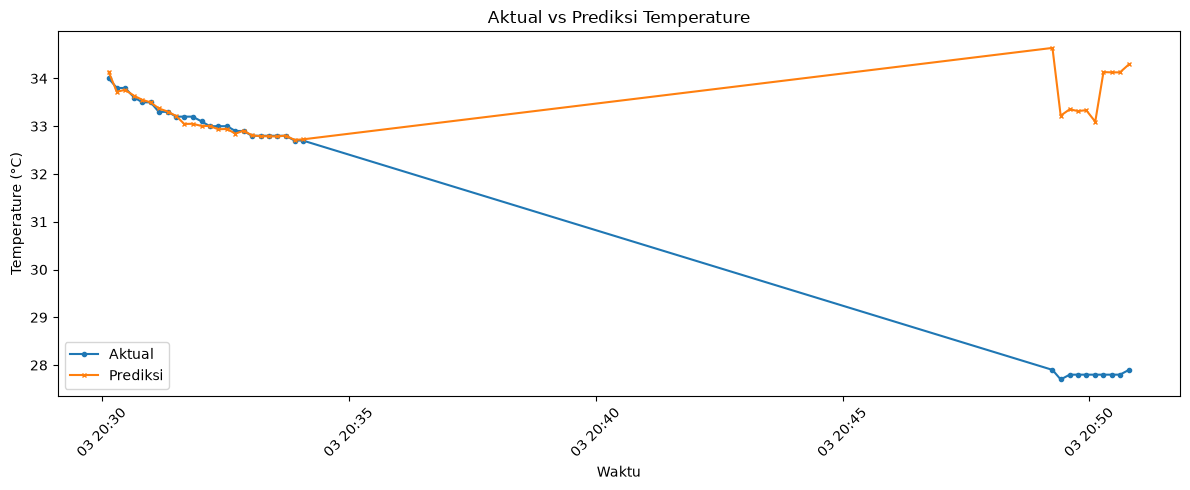

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. LOAD DATA
df = pd.read_csv("suhu_panas.csv", sep=";")
df.columns = df.columns.str.strip()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Humidity"] = pd.to_numeric(df["Humidity"].astype(str).str.strip())
df["Temperature"] = pd.to_numeric(df["Temperature"].astype(str).str.strip())
df = df.sort_values("Timestamp").reset_index(drop=True)

print("Total baris:", len(df))
print("Rentang:", df["Timestamp"].min(), "→", df["Timestamp"].max())

# 2. FEATURE ENGINEERING
TARGET = "Temperature"
LAGS = [1, 2, 3, 5, 10, 20]

def buat_fitur(df):
    d = df.copy()
    for lag in LAGS:
        d[f"temp_lag{lag}"] = d["Temperature"].shift(lag)
        d[f"hum_lag{lag}"]  = d["Humidity"].shift(lag)
    d["jam"]   = d["Timestamp"].dt.hour
    d["menit"] = d["Timestamp"].dt.minute
    d["diff_temp"] = d["Temperature"].diff()
    d["roll_temp_5"] = d["Temperature"].rolling(5).mean()
    d["roll_hum_5"]  = d["Humidity"].rolling(5).mean()
    return d.dropna().reset_index(drop=True)

df_feat = buat_fitur(df)
print("Setelah fitur:", df_feat.shape)

FEATURES = [c for c in df_feat.columns if c not in ["Timestamp", TARGET]]

# 3. SPLIT TIME-BASED 
n = len(df_feat)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train = df_feat.iloc[:train_end]
val   = df_feat.iloc[train_end:val_end]
test  = df_feat.iloc[val_end:]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# 4. LATIH MODEL
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# 5. EVALUASI MODEL
def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:5s} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")

eval_model("VAL",  y_val,  model.predict(X_val))
eval_model("TEST", y_test, model.predict(X_test))

# 6. PREDIKSI
pred_test = model.predict(X_test)
hasil = test[["Timestamp", "Temperature", "Humidity"]].copy()
hasil["Prediksi"] = pred_test
hasil["Error"]    = hasil["Temperature"] - hasil["Prediksi"]

# 7. DECISION RULES
def keputusan(row, suhu_max=34.0, suhu_min=25.0, hum_min=40.0):
    if row["Prediksi"] > suhu_max:
        return "NYALAKAN_KIPAS"
    elif row["Prediksi"] < suhu_min:
        return "NYALAKAN_HEATER"
    elif row["Humidity"] < hum_min:
        return "NYALAKAN_HUMIDIFIER"
    else:
        return "NORMAL"

hasil["Aksi"] = hasil.apply(keputusan, axis=1)

print("\nDistribusi aksi:")
print(hasil["Aksi"].value_counts())

# 8. SIMPAN
hasil.to_csv("hasil_prediksi.csv", index=False)
print("\n Disimpan ke hasil_prediksi.csv")

# 9. VISUALISASI
plt.figure(figsize=(12, 5))
plt.plot(hasil["Timestamp"], hasil["Temperature"], label="Aktual", marker="o", ms=3)
plt.plot(hasil["Timestamp"], hasil["Prediksi"],   label="Prediksi", marker="x", ms=3)
plt.xlabel("Waktu"); plt.ylabel("Temperature (°C)")
plt.title("Aktual vs Prediksi Temperature")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("plot_prediksi.png", dpi=120)
print("Plot disimpan ke plot_prediksi.png")

Total baris: 263
Rentang: 2026-10-03 20:18:59 → 2026-10-03 21:18:54
Setelah fitur: (243, 20)
Train: 170 | Val: 36 | Test: 37
VAL   | MAE: 0.407 | RMSE: 0.440
TEST  | MAE: 0.544 | RMSE: 0.572

Distribusi aksi:
Aksi
NYALAKAN_HUMIDIFIER    35
NORMAL                  2
Name: count, dtype: int64

 Disimpan ke hasil_prediksi.csv
Plot disimpan ke plot_prediksi.png


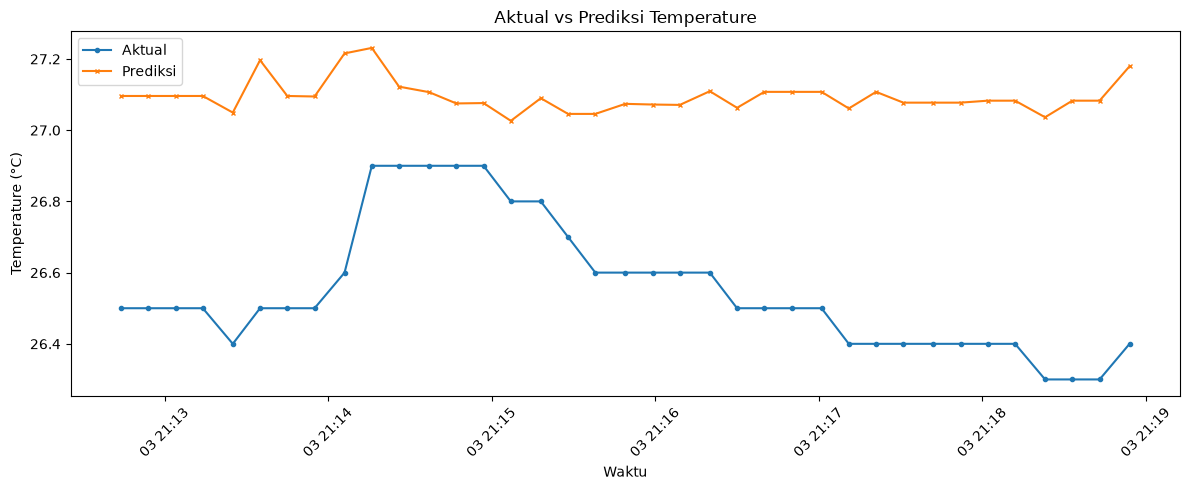

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. LOAD DATA
df = pd.read_csv("suhu_dingin.csv", sep=";")
df.columns = df.columns.str.strip()
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df["Humidity"] = pd.to_numeric(df["Humidity"].astype(str).str.strip())
df["Temperature"] = pd.to_numeric(df["Temperature"].astype(str).str.strip())
df = df.sort_values("Timestamp").reset_index(drop=True)

print("Total baris:", len(df))
print("Rentang:", df["Timestamp"].min(), "→", df["Timestamp"].max())

# 2. FEATURE ENGINEERING
TARGET = "Temperature"
LAGS = [1, 2, 3, 5, 10, 20]

def buat_fitur(df):
    d = df.copy()
    for lag in LAGS:
        d[f"temp_lag{lag}"] = d["Temperature"].shift(lag)
        d[f"hum_lag{lag}"]  = d["Humidity"].shift(lag)
    d["jam"]   = d["Timestamp"].dt.hour
    d["menit"] = d["Timestamp"].dt.minute
    d["diff_temp"] = d["Temperature"].diff()
    d["roll_temp_5"] = d["Temperature"].rolling(5).mean()
    d["roll_hum_5"]  = d["Humidity"].rolling(5).mean()
    return d.dropna().reset_index(drop=True)

df_feat = buat_fitur(df)
print("Setelah fitur:", df_feat.shape)

FEATURES = [c for c in df_feat.columns if c not in ["Timestamp", TARGET]]

# 3. SPLIT TIME-BASED
n = len(df_feat)
train_end = int(n * 0.7)
val_end   = int(n * 0.85)

train = df_feat.iloc[:train_end]
val   = df_feat.iloc[train_end:val_end]
test  = df_feat.iloc[val_end:]

X_train, y_train = train[FEATURES], train[TARGET]
X_val,   y_val   = val[FEATURES],   val[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f"Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

# 4. LATIH MODEL
model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

# 5. EVALUASI
def eval_model(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{name:5s} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")

eval_model("VAL",  y_val,  model.predict(X_val))
eval_model("TEST", y_test, model.predict(X_test))

# 6. PREDIKSI
pred_test = model.predict(X_test)
hasil = test[["Timestamp", "Temperature", "Humidity"]].copy()
hasil["Prediksi"] = pred_test
hasil["Error"]    = hasil["Temperature"] - hasil["Prediksi"]

# 7. DECISION RULES
def keputusan(row, suhu_max=34.0, suhu_min=25.0, hum_min=40.0):
    if row["Prediksi"] > suhu_max:
        return "NYALAKAN_KIPAS"
    elif row["Prediksi"] < suhu_min:
        return "NYALAKAN_HEATER"
    elif row["Humidity"] < hum_min:
        return "NYALAKAN_HUMIDIFIER"
    else:
        return "NORMAL"

hasil["Aksi"] = hasil.apply(keputusan, axis=1)

print("\nDistribusi aksi:")
print(hasil["Aksi"].value_counts())

# 8. SIMPAN 
hasil.to_csv("hasil_prediksi.csv", index=False)
print("\n Disimpan ke hasil_prediksi.csv")

# 9. VISUALISASI 
plt.figure(figsize=(12, 5))
plt.plot(hasil["Timestamp"], hasil["Temperature"], label="Aktual", marker="o", ms=3)
plt.plot(hasil["Timestamp"], hasil["Prediksi"],   label="Prediksi", marker="x", ms=3)
plt.xlabel("Waktu"); plt.ylabel("Temperature (°C)")
plt.title("Aktual vs Prediksi Temperature")
plt.legend(); plt.xticks(rotation=45); plt.tight_layout()
plt.savefig("plot_prediksi.png", dpi=120)
print("Plot disimpan ke plot_prediksi.png")